In [29]:
def create_superposition(qc, n):
    qc.h(range(n))

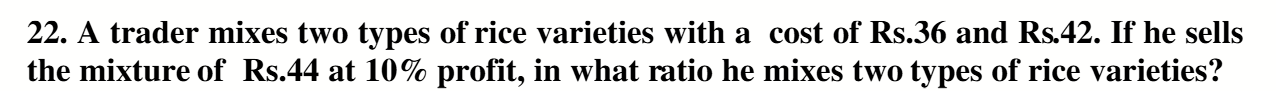

In [30]:
def oracle(qc, marked_states):

    for state in marked_states:
        mark_single_state(qc, state)

In [31]:
def mark_single_state(qc, state):

    n = len(state)

    # Apply X on every 0 bit
    for i, bit in enumerate(state):
        if bit == '0':
            qc.x(i)

    # Multi Controlled Z
    qc.h(n-1)
    qc.mcx(list(range(n-1)), n-1)
    qc.h(n-1)

    # Undo X
    for i, bit in enumerate(state):
        if bit == '0':
            qc.x(i)

In [32]:
def diffuser(qc, n):

    qc.h(range(n))
    qc.x(range(n))

    qc.h(n-1)
    qc.mcx(list(range(n-1)), n-1)
    qc.h(n-1)

    qc.x(range(n))
    qc.h(range(n))

In [33]:
def grover_iteration(qc, marked_states, n):

    oracle(qc, marked_states)
    diffuser(qc, n)

In [34]:
# n = int(input("Number of qubits: "))
n=3
k=1

# k = int(input("Number of marked states: "))

marked_states = []

for _ in range(k):
    marked_states.append(input())

In [35]:
import math

from qiskit import (
    QuantumCircuit,
    QuantumRegister,
    ClassicalRegister,
    transpile
)

from qiskit_aer import AerSimulator
from qiskit.quantum_info import Statevector

from qiskit.visualization import plot_histogram

import matplotlib.pyplot as plt

In [36]:
qc = QuantumCircuit(n)

create_superposition(qc, n)

state = Statevector.from_instruction(qc)

print("State after Superposition:")
print(state)

State after Superposition:
Statevector([0.35355339+0.j, 0.35355339+0.j, 0.35355339+0.j,
             0.35355339+0.j, 0.35355339+0.j, 0.35355339+0.j,
             0.35355339+0.j, 0.35355339+0.j],
            dims=(2, 2, 2))


In [37]:
oracle(qc, marked_states)

state = Statevector.from_instruction(qc)

print("State after Oracle:")
print(state)

State after Oracle:
Statevector([ 0.35355339+0.j,  0.35355339+0.j,  0.35355339+0.j,
              0.35355339+0.j,  0.35355339+0.j, -0.35355339+0.j,
              0.35355339+0.j,  0.35355339+0.j],
            dims=(2, 2, 2))


In [38]:
grover_iteration(qc, marked_states, n)